# amazon inventory / demand forecasting project
basically trying to figure out why so much money gets stuck in wrong inventory - either too much stock of stuff that doesnt sell, or not enough of stuff that does. using the kaggle product demand dataset to build a simple forecast and see what i can learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Historical Product Demand.csv')
df.shape

(1048575, 5)

## cleaning the data
first thing i noticed - Order_Demand was loading in as text not numbers. turns out some values were like (1000) instead of -1000, thats an accounting thing where brackets = negative. easy to miss this and just strip the brackets without flipping the sign, which is exactly what i did the first time and it silently turned all my negative/return values into positive ones lol

In [3]:
# gotta flag which rows have brackets BEFORE i touch the column
# if i convert to numeric first, the bracket info is gone and i cant recover it
is_negative = df['Order_Demand'].astype(str).str.contains(r'\(', regex=True)
print('rows with brackets:', is_negative.sum())

rows with brackets: 10469


In [4]:
# now strip the brackets, still just text at this point
cleaned = (
    df['Order_Demand']
    .astype(str)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

In [5]:
# convert to numbers now that brackets are gone
cleaned = pd.to_numeric(cleaned, errors='coerce')

# flip sign only for the rows that originally had brackets
cleaned[is_negative] = cleaned[is_negative] * -1

df['Order_Demand'] = cleaned
print('min:', df['Order_Demand'].min())
print('max:', df['Order_Demand'].max())
print('nulls:', df['Order_Demand'].isna().sum())

min: -999000
max: 4000000
nulls: 0


min is actually negative now which is what i wanted to confirm - means the sign fix worked properly this time

In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Order_Demand'] = df['Order_Demand'].fillna(0)

## duplicates
next thing - there were a bunch of duplicate looking rows. my first instinct was to just drop them but then i thought about it more - a warehouse can genuinely get multiple separate orders for the same product on the same day, so those arent really duplicates, theyre just multiple real orders that need to be added together not deleted.

checked this by comparing full row duplicates vs duplicates on just (product, warehouse, date) ignoring the demand column. if the second number is way higher than the first, that means demand is different for the same product/warehouse/date combo - so its actually a second real order, not a copy paste error

In [7]:
print('full row dupes:', df.duplicated().sum())
print('same product/warehouse/date dupes:', df.duplicated(subset=['Product_Code','Warehouse','Date']).sum())

full row dupes: 122423
same product/warehouse/date dupes: 413940


since these numbers were pretty different, going with groupby + sum instead of just dropping - this fixes the grain properly and doesnt lose any real demand

In [8]:
df = (
    df.groupby(['Product_Code','Warehouse','Product_Category','Date'], as_index=False, dropna=False)
    ['Order_Demand'].sum()
)
df.shape

(634635, 5)

## missing dates
around 11k rows had no date at all. before just dropping them i checked if they were spread out evenly or concentrated somewhere - turns out literally all of them came from one single warehouse (Whse_A), which is about 7.3% of that warehouses rows and roughly 1% of the whole dataset.

since im forecasting at the category level and not comparing warehouses against each other, dropping these is fine - just noting that Whse_A's demand history is probably a little undercounted because of this

In [9]:
print(df[df['Date'].isna()].groupby('Warehouse').size())

Warehouse
Whse_A    82
dtype: int64


In [10]:
df = df.dropna(subset=['Date']).reset_index(drop=True)
df.shape

(634553, 5)

## outliers
tried a basic IQR check on the whole Order_Demand column first, and it flagged like 18% of the data as outliers which felt way too high. turns out the issue was doing IQR globally doesnt work when you have products with totally different normal order sizes - a huge order for a big product looks like an outlier compared to a tiny product, even if its completely normal for that specific product.

fixed this by doing IQR per product instead of globally, which brought it down to about 9%. still decided to just drop these since the dataset is big enough that losing 9% doesnt hurt much, and i wanted to focus time on the actual forecasting part instead of perfecting outlier detection

In [11]:
def get_bounds(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({'lower': q1 - 1.5*iqr, 'upper': q3 + 1.5*iqr})

bounds = df.groupby('Product_Code')['Order_Demand'].apply(get_bounds).unstack()
df = df.merge(bounds, on='Product_Code', how='left')
df['is_outlier'] = (df['Order_Demand'] < df['lower']) | (df['Order_Demand'] > df['upper'])
print(df['is_outlier'].sum(), df['is_outlier'].mean()*100)

58715 9.252970201070674


In [12]:
df = df[~df['is_outlier']].drop(columns=['lower','upper','is_outlier']).reset_index(drop=True)
df.shape

(575838, 5)

## checking if product level forecasting even makes sense
before jumping into forecasting i wanted to check how much history each product actually has, since a moving average is useless if theres barely any data. median product only had about 150 rows spread across 6 years which is really sparse - like 2 orders a month. so forecasting individual products isnt really reliable for most of them, going with category level instead since that pools enough data together

In [13]:
df.groupby('Product_Code').size().describe()

count    2160.000000
mean      266.591667
std       314.525829
min         1.000000
25%        77.000000
50%       149.000000
75%       322.000000
max      2099.000000
dtype: float64

## building the weekly time series per category
aggregating daily transaction rows up to weekly totals per category, since daily is too sparse/noisy and weekly gives a cleaner signal to actually see trends

In [14]:
weekly_cat = (
    df.groupby(['Product_Category', pd.Grouper(key='Date', freq='W')])['Order_Demand']
    .sum()
    .reset_index()
)
weekly_cat['Product_Category'].value_counts().head(10)

Product_Category
Category_007    270
Category_019    270
Category_028    269
Category_021    268
Category_006    268
Category_001    266
Category_009    266
Category_015    265
Category_005    265
Category_024    265
Name: count, dtype: int64

picking the top few categories by data volume so the series is clean and continuous, not full of gaps

In [15]:
top_category = weekly_cat['Product_Category'].value_counts().index[0]
cat_data = weekly_cat[weekly_cat['Product_Category'] == top_category].sort_values('Date').reset_index(drop=True)
cat_data.head()

,Product_Category,Date,Order_Demand
0,Category_007,2011-10-23,-2
1,Category_007,2011-11-06,-500
2,Category_007,2011-12-04,2
3,Category_007,2011-12-11,240
4,Category_007,2011-12-18,549


## moving average forecast
the whole idea here is simple - take the last N weeks and average them, thats your prediction for the next week. tried two window sizes to see which one actually tracks real demand better

In [16]:
cat_data['MA_4'] = cat_data['Order_Demand'].rolling(window=4).mean()
cat_data['MA_12'] = cat_data['Order_Demand'].rolling(window=12).mean()

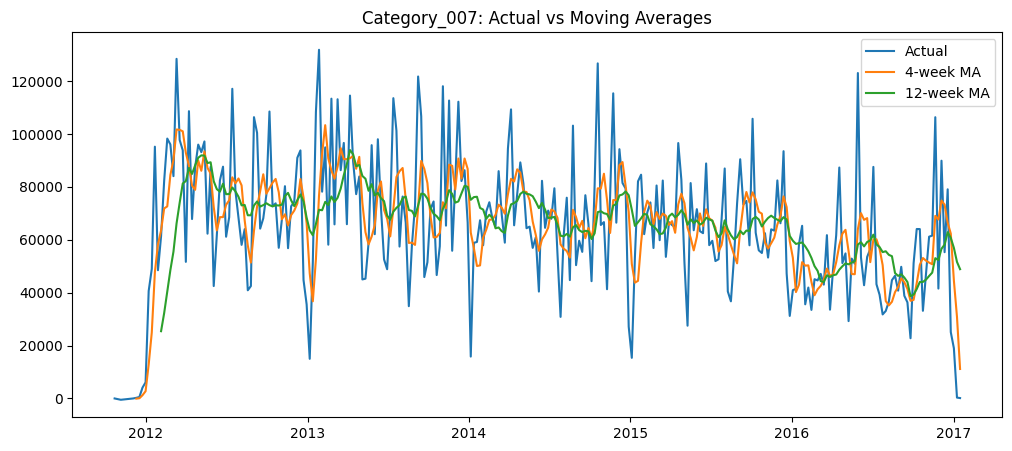

In [17]:
plt.figure(figsize=(12,5))
plt.plot(cat_data['Date'], cat_data['Order_Demand'], label='Actual')
plt.plot(cat_data['Date'], cat_data['MA_4'], label='4-week MA')
plt.plot(cat_data['Date'], cat_data['MA_12'], label='12-week MA')
plt.legend()
plt.title(f'{top_category}: Actual vs Moving Averages')
plt.show()

you can see the 12 week line is way smoother but lags behind the real spikes more, makes sense since its averaging over a longer stretch of time so it reacts slower to actual changes

In [18]:
mae_4 = (cat_data['Order_Demand'] - cat_data['MA_4']).abs().mean()
mae_12 = (cat_data['Order_Demand'] - cat_data['MA_12']).abs().mean()
print('MAE 4-week:', mae_4)
print('MAE 12-week:', mae_12)

MAE 4-week: 14950.050561797752
MAE 12-week: 16652.090411840414


4-week window won here with lower error, which tells me this category's demand is pretty volatile - shorter windows react faster to swings so they end up closer to the real number on average. checked this across a couple more categories and same pattern held, so going with 4-week as the better choice for this dataset

## forecasting the next few weeks
everything above was basically backtesting - checking how close the moving average would have been on data i already have. now actually predicting weeks that havent happened yet.

important thing to keep in mind - week 1 ahead uses real actual data, but week 2 ahead has to use the week 1 *forecast* as if it were real, and week 3 uses week 2's forecast, and so on. so the errors kind of stack up the further out you go. week+1 is the most trustworthy number here, the rest get shakier

In [19]:
history = cat_data['Order_Demand'].tolist()
forecasts = []

for _ in range(4):
    next_val = pd.Series(history[-4:]).mean()
    forecasts.append(next_val)
    history.append(next_val)

print(f'next 4 weeks forecast for {top_category}:')
print(forecasts)

next 4 weeks forecast for Category_007:
[np.float64(11141.5), np.float64(7656.375), np.float64(4817.46875), np.float64(5940.8359375)]


## takeaways
- Order_Demand had accounting-style negative notation `(1000)` = -1000, easy bug to introduce if you just strip brackets without flipping the sign
- duplicate looking rows werent actually errors, they were real multiple orders for the same product/warehouse/day - summed them instead of dropping to keep the real demand total
- ~11k missing dates were all from one warehouse specifically, not spread randomly, so noted that as a limitation instead of pretending it doesnt matter
- global outlier detection breaks when products have very different normal order sizes, doing it per product fixed the over-flagging problem
- most products dont have enough order history to forecast individually, so went with category-level forecasting instead
- shorter moving average windows (4-week) beat longer ones (12-week) here, meaning demand at category level is fairly volatile, not smooth/trending
- multi-step forecasts get less reliable further out since later predictions are built on earlier predictions, not real data